# 02. Data Preprocessing & Feature Engineering

**Dataset:** NYC TLC Green Taxi trip records (2024–2026)  
**Target variable:** `tip_amount` — Regression problem  
**Scope:** credit-card trips only (payment_type == 1), since cash tips are not recorded

## Sections
0. Imports & Constants  
1. Load Raw Data  
2. Exploratory Data Analysis  
3. Data Cleaning  
4. Define Target Variable  
5. Feature Engineering  
6. Reference / Analysis Split  
7. Save to Hopsworks Feature Store  
8. Save Intermediate Files (for Kedro pipelines)

## 0. Imports & Constants

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from typing import Union
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature store
import hopsworks

# Paths (relative to notebooks/ folder)
RAW_DATA_PATH = "../data/01_raw/green_taxi"
INTERMEDIATE_PATH = "../data/02_intermediate"

# -----------------------------
# DATA SPLITS
# -----------------------------

# ML Training
TRAIN_YEARS = [2024, 2025]
VALIDATION_YEARS = [2025]


RANDOM_STATE = 42

# Target
TARGET_COL = "tip_amount"

# Hopsworks
FS_API_KEY = os.getenv("FS_API_KEY", "YOUR_API_KEY_HERE")
FS_PROJECT_NAME = os.getenv("FS_PROJECT_NAME", "mlops_novaims")

print("Imports OK")

Imports OK


## 1. Load Raw Data

We load all monthly parquet files and concatenate them. The folder structure is:
```
data/01_raw/green_taxi/{year}/green_tripdata_{year}-{month}.parquet
```

In [2]:
def load_parquet_folder(base_path: str, years: list) -> pd.DataFrame:
    """Load all monthly parquet files for the given years."""
    
    files = []

    for year in years:
        pattern = os.path.join(base_path, str(year), "*.parquet")
        files.extend(sorted(glob.glob(pattern)))

    print(f"Loading {len(files)} parquet files...")

    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

    return df

In [3]:
ml_raw = load_parquet_folder(RAW_DATA_PATH, [2024, 2025])

Loading 24 parquet files...
Loaded 1,251,593 rows, 21 columns


## Data Split

In [4]:
#ml_raw["lpep_pickup_datetime"] = pd.to_datetime(
#    ml_raw["lpep_pickup_datetime"]
#)

In [5]:
#train_df = ml_raw[
#    ml_raw["lpep_pickup_datetime"] < "2025-07-01"
#].copy()

#val_df = ml_raw[
#    ml_raw["lpep_pickup_datetime"] >= "2025-07-01"
#].copy()

In [6]:
#print(f"Train rows      : {len(train_df):,}")
#print(f"Validation rows : {len(val_df):,}")

#print("\nTrain period:")
#print(
#    train_df["lpep_pickup_datetime"].min(),
#    "->",
#    train_df["lpep_pickup_datetime"].max()
#)

#print("\nValidation period:")
#print(
#    val_df["lpep_pickup_datetime"].min(),
#    "->",
#    val_df["lpep_pickup_datetime"].max()
#)

## 3. Data Cleaning and Preprocessing

Steps:
- Drop `ehail_fee` (100% null)
- Filter to credit-card trips only (`payment_type == 1`)
- Remove rows with invalid trip distances (≤ 0)
- Remove rows with negative fares
- Remove outliers (extreme distances / durations)
- Remove rows with no pickup/dropoff timestamps

In [7]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean raw green taxi data."""
    n_start = len(df)
    
    # Drop fully null column
    df = df.drop(columns=['ehail_fee'], errors='ignore')
    
    # Filter to credit card trips only (cash tips not recorded)
    df = df[df['payment_type'] == 1].copy()
    print(f"After credit card filter: {len(df):,} ({len(df)/n_start*100:.1f}% of original)")
    
    # Drop rows missing essential fields
    df = df.dropna(subset=['lpep_pickup_datetime', 'lpep_dropoff_datetime',
                            'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount'])
    
    # Filter valid trip distances (> 0 and < 100 miles)
    df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
    
    # Filter valid fares (> 0 and < 500)
    df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
    
    # Filter valid timestamps (no future dates, no dates before 2024)
    df = df[df['lpep_pickup_datetime'] >= '2024-01-01']
    df = df[df['lpep_dropoff_datetime'] > df['lpep_pickup_datetime']]
    
    # Compute duration for outlier removal
    duration_min = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60
    # Keep trips between 1 and 180 minutes
    df = df[(duration_min >= 1) & (duration_min <= 180)]

    #Clean target column
    df = df.dropna(subset=["tip_amount"])
    df = df[df["tip_amount"] >= 0]
    df = df[df["tip_amount"] < 200]

    #Drop duplicates
    df = df.drop_duplicates()

    #Drop small number of missing values
    df = df.dropna(subset=["trip_type"])

    #Remove cbd_congestion_fee as it doesn't add information and has a lot of missing data
    df = df.drop(columns=["cbd_congestion_fee"], errors="ignore")
    
    print(f"After cleaning: {len(df):,} rows remaining")
    return df.reset_index(drop=True)


#train_clean = clean_data(train_df)
print()
#val_clean = clean_data(val_df)
data_clean =clean_data(ml_raw)


After credit card filter: 861,299 (68.8% of original)
After cleaning: 806,937 rows remaining


## 4. Define Target Variable

The target is going to be **`tip_amount`**

## 5. Feature Engineering

New features derived from raw columns:

| Feature | Description | Source |
|---|---|---|
| `trip_duration_min` | Trip duration in minutes | pickup/dropoff datetime |
| `pickup_hour` | Hour of pickup (0–23) | lpep_pickup_datetime |
| `pickup_dayofweek` | Day of week (0=Mon, 6=Sun) | lpep_pickup_datetime |
| `pickup_month` | Month (1–12) | lpep_pickup_datetime |
| `is_weekend` | 1 if Saturday or Sunday | pickup_dayofweek |
| `is_rush_hour` | 1 if weekday 7–9am or 5–7pm | pickup_hour + is_weekend |
| `is_night` | 1 if pickup between 10pm–5am | pickup_hour |
| `is_airport` | 1 if PU or DO at JFK/LGA/EWR | PULocationID / DOLocationID |


In [8]:
# NYC airport zone IDs (JFK=132, LGA=138, EWR=1)
AIRPORT_ZONE_IDS = {1, 132, 138}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer features from raw green taxi trip data."""
    df = df.copy()
    
    # --- Temporal features ---
    pickup = pd.to_datetime(df['lpep_pickup_datetime'])
    dropoff = pd.to_datetime(df['lpep_dropoff_datetime'])
    
    df['trip_duration_min'] = (dropoff - pickup).dt.total_seconds() / 60
    df['pickup_hour']       = pickup.dt.hour
    df['pickup_dayofweek']  = pickup.dt.dayofweek  # 0=Monday, 6=Sunday
    df['pickup_month']      = pickup.dt.month
    
    df['is_weekend']   = (df['pickup_dayofweek'] >= 5).astype(int)
    df['is_rush_hour'] = (
        (df['is_weekend'] == 0) &
        (df['pickup_hour'].isin(range(7, 10)) | df['pickup_hour'].isin(range(17, 20)))
    ).astype(int)
    df['is_night'] = (df['pickup_hour'].isin(list(range(22, 24)) + list(range(0, 6)))).astype(int)
    
    
    # --- Location features ---
    df['is_airport'] = (
        df['PULocationID'].isin(AIRPORT_ZONE_IDS) |
        df['DOLocationID'].isin(AIRPORT_ZONE_IDS)
    ).astype(int)
    
    
    return df


#train_feat = engineer_features(train_clean)
#val_feat = engineer_features(val_clean)

#print("Train features shape:", train_feat.shape)
#print("Val features shape: ", val_feat.shape)

data_feat = engineer_features(data_clean)
print("Val features shape: ", data_feat.shape)

Val features shape:  (806937, 27)


In [9]:
# Preview engineered features
new_cols = ['trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
            'is_weekend', 'is_rush_hour', 'is_night','is_airport']
data_feat[new_cols].head()

,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,11.500000,0,0,1,0,0,1,0
1,20.866667,0,0,1,0,0,1,0
2,19.033333,0,0,1,0,0,1,0
3,10.983333,0,0,1,0,0,1,0
4,16.700000,0,0,1,0,0,1,0


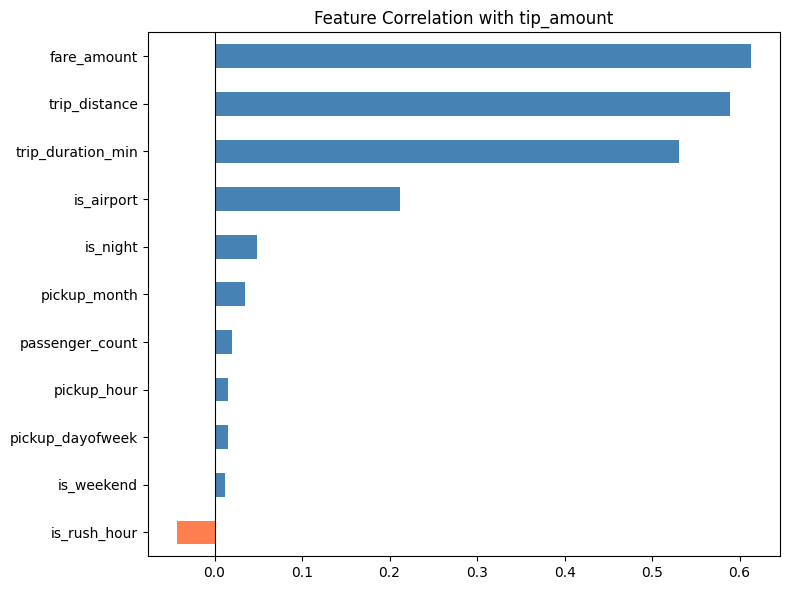

In [10]:
# Correlation of engineered features with target
numeric_cols = ['trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'is_weekend', 'is_rush_hour', 'is_night',
                 'is_airport',"tip_amount",
                'trip_distance', 'fare_amount', 'passenger_count',]

corr = data_feat[numeric_cols].corr()['tip_amount'].drop('tip_amount').sort_values()

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['coral' if v < 0 else 'steelblue' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with tip_amount')
plt.tight_layout()
plt.show()

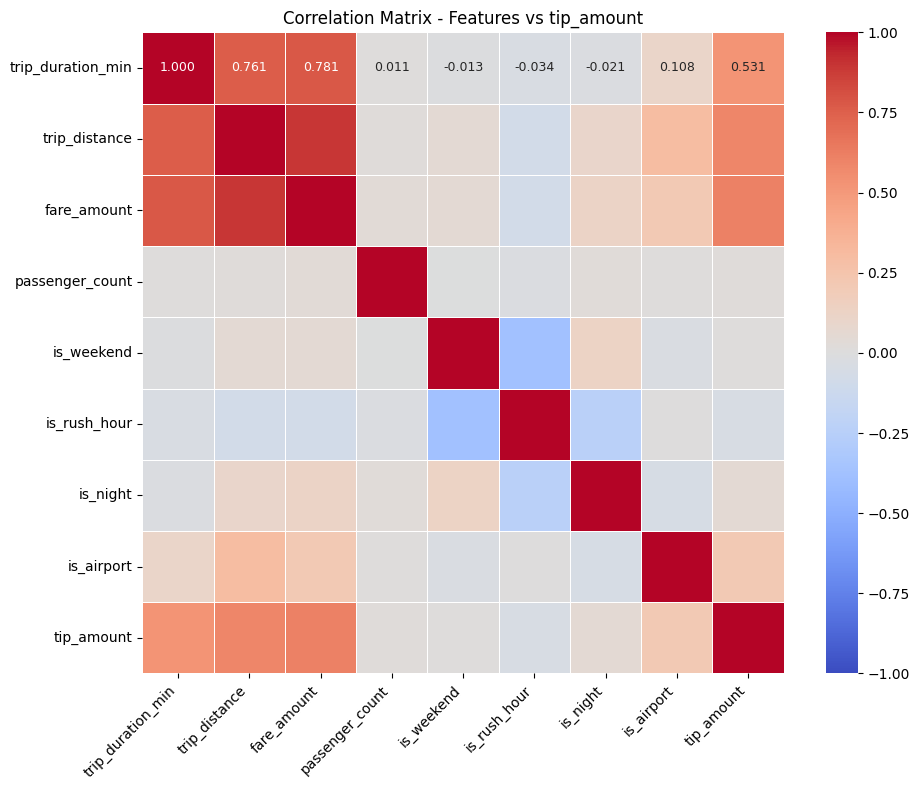

In [11]:
numeric_cols = [
    'trip_duration_min', 'trip_distance', 'fare_amount', 'passenger_count',
    'is_weekend', 'is_rush_hour', 'is_night', 'is_airport', 'tip_amount'
]

corr_matrix = data_feat[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 9})
plt.title('Correlation Matrix - Features vs tip_amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Select Final Feature Set

Drop columns that are:
- **Leakage**:  `total_amount` (contain or derive the target)
- **Raw temporal**: `lpep_pickup_datetime`, `lpep_dropoff_datetime` (replaced by engineered features)
- **Redundant**: `payment_type` (we filtered to credit card only, all == 1)
- **Administrative**: `store_and_fwd_flag`, `VendorID`

In [12]:
COLS_TO_DROP = [
    'total_amount',          # leakage (includes tip)
    'payment_type',          # constant after filtering (all == 1)
    "lpep_dropoff_datetime",
    'store_and_fwd_flag',    # administrative
    'VendorID',              # administrative
]

def select_features(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = [c for c in COLS_TO_DROP if c in df.columns]
    return df.drop(columns=cols_to_drop)

#train_final = select_features(train_feat)
#val_final = select_features(val_feat)
data_final = select_features(data_feat)

print("Final feature columns:")
print(data_final.columns.tolist())
#print(f"\nTrain shape: {train_final.shape}")
#print(f"Val shape:  {val_final.shape}")

print(f"Data shape:  {data_final.shape}")

Final feature columns:
['lpep_pickup_datetime', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'trip_type', 'congestion_surcharge', 'trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_airport']
Data shape:  (806937, 22)


In [13]:
# Final null check
print("Nulls in reference features:")
print(data_final.isnull().sum()[data_final.isnull().sum() > 0])

print("\nNull check after fill: OK" if data_final.isnull().sum().sum() == 0 else "Still has nulls!")

Nulls in reference features:
Series([], dtype: int64)

Null check after fill: OK


In [14]:
data_final

,lpep_pickup_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,...,trip_type,congestion_surcharge,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,2024-01-01 00:46:55,1.0,236,239,1.0,1.98,12.8,1.00,0.5,3.61,...,1.0,2.75,11.500000,0,0,1,0,0,1,0
1,2024-01-01 00:31:42,1.0,65,170,5.0,6.54,30.3,1.00,0.5,7.11,...,1.0,2.75,20.866667,0,0,1,0,0,1,0
2,2024-01-01 00:30:21,1.0,74,262,1.0,3.08,19.8,1.00,0.5,3.00,...,1.0,2.75,19.033333,0,0,1,0,0,1,0
3,2024-01-01 00:32:38,1.0,74,243,1.0,5.14,22.6,1.00,0.5,6.28,...,1.0,0.00,10.983333,0,0,1,0,0,1,0
4,2024-01-01 00:43:41,1.0,33,209,1.0,2.00,17.0,3.75,1.5,2.00,...,1.0,2.75,16.700000,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806932,2025-12-31 23:06:34,1.0,74,43,1.0,1.50,10.0,1.00,0.5,1.00,...,1.0,0.00,7.900000,23,2,12,0,0,1,0
806933,2025-12-31 23:21:11,1.0,43,236,1.0,1.19,7.2,1.00,0.5,1.87,...,1.0,2.75,4.250000,23,2,12,0,0,1,0
806934,2025-12-31 23:48:03,1.0,75,74,1.0,1.33,7.9,1.00,0.5,2.08,...,1.0,0.00,4.000000,23,2,12,0,0,1,0
806935,2025-12-31 23:05:12,1.0,74,75,1.0,1.30,7.9,1.00,0.5,0.00,...,1.0,0.00,4.900000,23,2,12,0,0,1,0


## 7. Save to Hopsworks Feature Store

We create one feature groups:
- **`green_taxi_features`** — reference (training) data from 2024 and 2025


In [15]:
#Create an ID to go for the feature store
data_final = data_final.reset_index(drop=True)
data_final["trip_id"] = data_final.index

In [16]:
# Securely load the environment variables from your .env file 
load_dotenv() 

True

In [17]:
def to_feature_store(data, group_name, feature_group_version, description, group_description):
    project = hopsworks.login(api_key_value=os.getenv("FS_API_KEY"), project=os.getenv("FS_PROJECT_NAME"))
    fs = project.get_feature_store()

    fg = fs.get_or_create_feature_group(
        name=group_name,
        version=feature_group_version,
        description=description,
        primary_key=["trip_id"],  
        event_time="lpep_pickup_datetime",  
        online_enabled=False,  
        time_travel_format="HUDI"
    )

    print(f"Uploading {group_name} to Hopsworks...")
    fg.insert(features=data, overwrite=False, storage="offline", write_options={"wait_for_job": True})
    
    for name, desc in group_description.items():
        fg.update_feature_description(name, desc)

    fg.statistics_config = {"enabled": True, "histograms": True, "correlations": True}
    fg.update_statistics_config()
    fg.compute_statistics()
    
    print(f"✅ Successfully ingested {group_name} into Hopsworks!")
    return fg

In [20]:
data_final.columns

Index(['lpep_pickup_datetime', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'trip_type',
       'congestion_surcharge', 'trip_duration_min', 'pickup_hour',
       'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour',
       'is_night', 'is_airport', 'trip_id'],
      dtype='object')

In [18]:
#Feature Group Dictionary
green_taxi_features = ['RatecodeID',
       'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance',
       'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'trip_type', 'congestion_surcharge',
       'trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
       'is_weekend', 'is_rush_hour', 'is_night', 'is_airport']

X_green_taxi = data_final[["trip_id", "lpep_pickup_datetime"] + green_taxi_features]

gree_taxi_descriptions_dict = {
    "trip_id": "Index of a trip",
    "lpep_pickup_datetime": "The date and time when the meter was engaged.",
    "RatecodeID": "The final rate code in effect at the end of the trip (1 = Standard rate; 2 = JFK; 3 = Newark; 4 = Nassau or Westchester; 5 = Negotiated fare; 6 = Group ride; 99 = Null/unknown).",
    "PULocationID": "TLC Taxi Zone in which the taximeter was engaged.",
    "DOLocationID": "TLC Taxi Zone in which the taximeter was disengaged.",
    "passenger_count": "The number of passengers in the vehicle.",
    "trip_distance": "The elapsed trip distance in miles reported by the taximeter.",
    "fare_amount": "The time-and-distance fare calculated by the meter.",
    "extra": "Miscellaneous extras and surcharges.",
    "mta_tax": "Tax that is automatically triggered based on the metered rate in use.",
    "tip_amount": "Tip amount - our target feature",
    "tolls_amount": "Total amount of all tolls paid in trip.",
    "improvement_surcharge": "Improve surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015.",
    "trip_type": "A code indicating whether the trip was a street-hail or a dispatch (1 = Street-hail; 2 = Dispatch).",
    "congestion_surcharge": "Total amount collected in trip for NYS congestion surcharge.",
    "trip_duration_min": "Trip duration in minutes.",
    "pickup_hour": "Hour of pickup (0-23).",
    "pickup_dayofweek": "Day of week (0=Mon, 6=Sun).",
    "pickup_month": "Month (1-12).",
    "is_weekend": "1 if Saturday or Sunday.",
    "is_rush_hour": "1 if weekday 7-9am or 5-7pm.",
    "is_night": "1 if pickup between 10pm-5am.",
    "is_airport": "1 if PU or DO at JFK/LGA/EWR."
}



In [19]:
to_feature_store(data=data_final,
                 group_name="green_taxi_features",
                 feature_group_version=1,
                 description=f"Features related to 2024 and 2025.",
                 group_description=gree_taxi_descriptions_dict)

2026-06-26 17:03:58,673 INFO: Initializing external client
2026-06-26 17:03:58,674 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-26 17:04:02,956 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32952
Uploading green_taxi_features to Hopsworks...


Uploading Dataframe: 100.00% |██████████| Rows 806937/806937 | Elapsed Time: 02:00 | Remaining Time: 00:00


Launching job: green_taxi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/32952/jobs/named/green_taxi_features_1_offline_fg_materialization/executions


2026-06-26 17:06:17,559 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2026-06-26 17:06:20,751 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2026-06-26 17:09:17,987 INFO: Waiting for execution to finish. Current state: SUCCEEDING. Final status: UNDEFINED
2026-06-26 17:09:24,349 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2026-06-26 17:09:24,541 INFO: Waiting for log aggregation to finish.
2026-06-26 17:09:33,339 INFO: Execution finished successfully.


KeyError: "'FeatureGroup' object has no feature or transformation called 'RatecodeID'."

## 8. Save Intermediate Files (for Kedro pipelines)

Save the engineered datasets to `data/02_intermediate/` so the Kedro `ingestion` and `split_data` pipelines can pick them up.

In [18]:
train_out_path = os.path.join(INTERMEDIATE_PATH, "train_data.parquet")
val_out_path = os.path.join(INTERMEDIATE_PATH, "val_data.parquet")

train_final.to_parquet(train_out_path, index=False)
val_final.to_parquet(val_out_path, index=False)

print(f"Saved train data: {train_out_path} ({len(train_final):,} rows)")
print(f"Saved validation data: {val_out_path} ({len(val_final):,} rows)")

Saved train data: ../data/02_intermediate\train_data.parquet (622,310 rows)
Saved validation data: ../data/02_intermediate\val_data.parquet (184,627 rows)


In [19]:
# # Summary
# print("=" * 50)
# print("FEATURE ENGINEERING SUMMARY")
# print("=" * 50)
# print(f"Reference (train) rows : {len(ref_final):,}")
# print(f"Analysis (batch) rows  : {len(ana_final):,}")
# print(f"Number of features     : {len(ref_final.columns) - 1}")
# print(f"Target column          : {TARGET_COL}")
# print(f"Target balance (ref)   : {ref_final[TARGET_COL].mean():.1%} tipped")
# print()
# print("Feature columns:")
# feature_cols = [c for c in ref_final.columns if c != TARGET_COL]
# for c in feature_cols:
#     print(f"  - {c}")